# Desing of experiments - Binding capacity

### Data importing

In [1]:
from pandas import read_csv

experiments = read_csv('../data/binding_capacity.csv', index_col="No")
experiments

,Cond [mS/cm],pH,Binding capacity
No,,,
1,5.0,4.5,96
2,15.0,4.5,102
3,5.0,5.5,137
4,15.0,5.5,4
5,5.0,5.0,139
6,15.0,5.0,54
7,10.0,4.5,119
8,10.0,5.5,84
9,10.0,5.0,121


### Creating a model

From the module: 'models.two_factors' we import LIQ class. 

The model represented by this class has Linear, Interaction and Quadratic terms:

$y = f(x_{1}, x_{2}) = \beta_{0} + \beta_{1} x_{1} + \beta_{11} x_{1}^{2} + \beta_{12} x_{1} x_{2} + \beta_{2} x_{2} + \beta_{22} x_{2}^{2} + e$

In [2]:
from models.two_factors import LIQ

model = LIQ(x_1 = "Cond [mS/cm]",
            x_2 = "pH",
            y_i = "Binding capacity",
            Data = experiments)

## Model validation

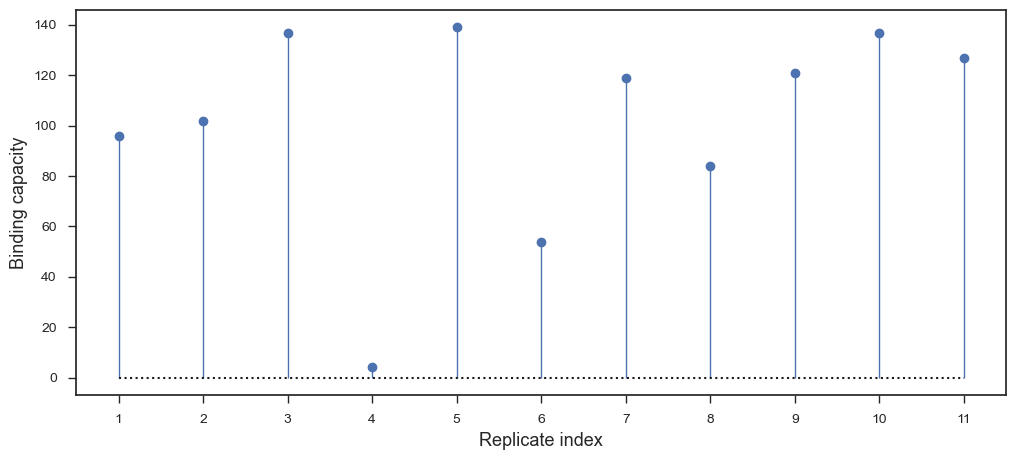

In [3]:
model.replicate_plot()

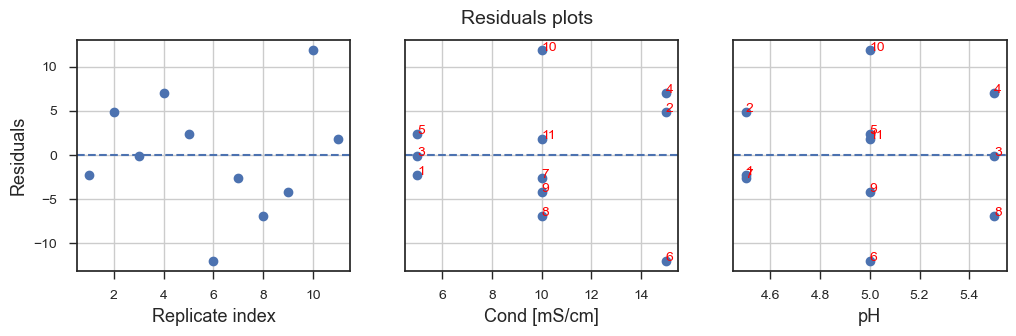

In [4]:
model.residuals_plot()

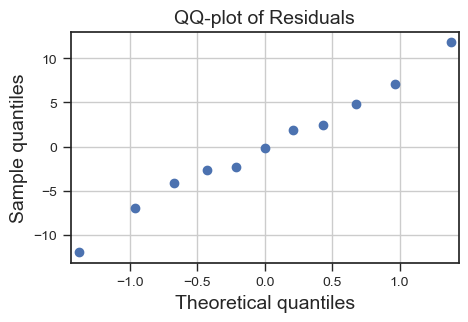

In [5]:
model.qq_plot()

In [6]:
model.shapiro

,Shapiro
p-value,0.999962


In [7]:
model.equation

beta_0 + beta_1*x_1 + beta_11*x_1**2 + beta_12*x_1*x_2 + beta_2*x_2 + beta_22*x_2**2

In [8]:
model.equation_subs

-0.955789473688492*x_1**2 - 13.9000000000327*x_1*x_2 + 81.5491228071946*x_1 - 75.5789473685885*x_2**2 + 864.122807019434*x_2 - 2330.89473684722

In [9]:
model.coefficients_stats

,beta_0,beta_1,beta_2,beta_12,beta_11,beta_22
Value,-2330.894737,81.549123,864.122807,-13.9,-0.955789,-75.578947
Standard error,591.579773,10.557157,237.298406,1.881536,0.236427,23.642654
t Statistic,-3.940119,7.724535,3.641503,-7.387582,-4.042645,-3.19672
p-value,0.010959,0.000581,0.01488,0.000715,0.009897,0.024083
Significance,*,***,*,***,**,*


In [10]:
model.anova

,df,SS,MS,F,p-value,Significance
Regression,5,16919.114434,3383.822887,38.233392,0.000548,***
Error,5,442.521930,88.504386,,,
Total,10,17361.636364,,,,


In [11]:
model.anova_error

,df,SS,MS,F,p-value,Significance
Lack of fit,3,311.79000,103.93,1.590725,0.408463,ns
Pure error,2,130.67000,65.335,,,
Error,5,442.52193,,,,


In [12]:
model.stats

,Model
R squared,0.974512
R squared adjusted,0.949023
RMSE,9.407677


In [13]:
model.DataFramePredicted

,Cond [mS/cm],pH,Binding capacity,Binding capacity^
No,,,,
1,5.0,4.5,96,98.29
2,15.0,4.5,102,97.12
3,5.0,5.5,137,137.12
4,15.0,5.5,4,-3.05
5,5.0,5.0,139,136.60
6,15.0,5.0,54,65.93
7,10.0,4.5,119,121.60
8,10.0,5.5,84,90.93
9,10.0,5.0,121,125.16


## Plots

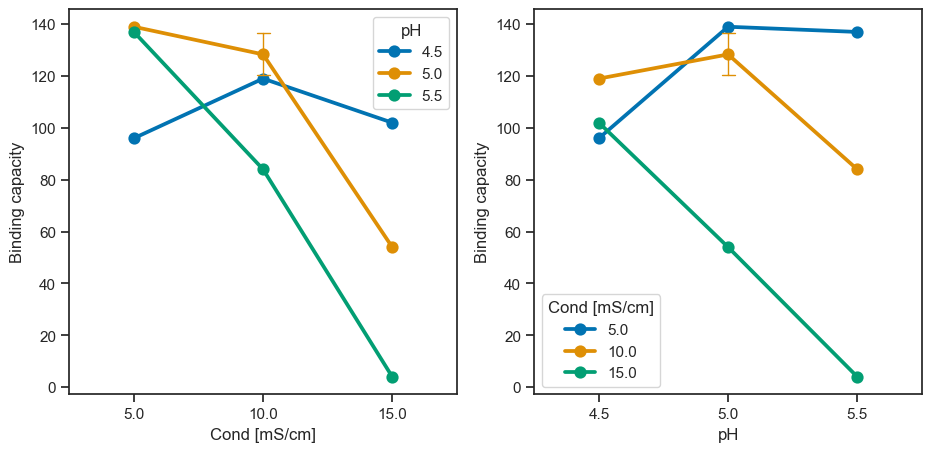

In [14]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
model.interaction_plot()

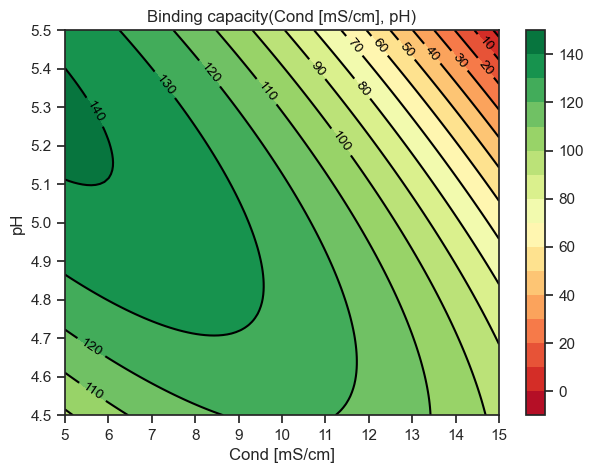

In [15]:
model.rsp(figure_size = (7,5), step_x = 1, step_y = 0.1, dpi = 100,
          contours_number = 15, contour_color = "black", contour_font_size = 10,  color_map = "RdYlGn")

Magnitude of gradient vector $\left|\vec{R}\right|$ equals 0 at $x_1$ and $x_2$ coordinates for which function $f\left(x_1,x_2\right)$ returns the critical points. Therefore, to find $x_1$ and $x_2$ values which return gradient vector $\left[0\hat{i},0\hat{j}\right]$, partial derivatives were solved for respective scalars of $\hat{i}$ and $\hat{j}$ vectors:

$\vec{R} = \nabla f(x_{1}, x_{2}) = \left[\frac{\partial f(x_1, x_2)}{\partial x_1} \hat i, \frac{\partial f(x_1, x_2)}{\partial x_2} \hat j \\ \right] = \left[0 \hat i , 0 \hat j \\ \right]$

$\frac{\partial f}{\partial x_1} (x_1, x_2) \hat i = \beta_1 + 2\beta_{11}x_1 + \beta_{12}x_2 = 0 \hat i$

$\frac{\partial f}{\partial x_2} (x_1, x_2) \hat j  = \beta_2 + 2\beta_{22}x_2 + \beta_{12}x_1 = 0 \hat j$

After combining formulas $\frac{\partial f}{\partial x_1} (x_1, x_2) \hat i$ and $\frac{\partial f}{\partial x_2} (x_1, x_2) \hat j$, $x_1$ and $x_2$ coordinates for which function returns critical points were conveniently calculated using linear algebra. The coefficient matrix took form of the Hessian matrix and its eigenvalues were used to classify the critical point.

In [17]:
model.solve()

Cond [mS/cm]: 3.30
pH: 5.41
Critical value: 142.51
Hessian matrix eigenvalues: [-0.63, -152.44]


Since loading the protein in the buffer with such low conductivity is not sensible, we focus on particular value of the 'Cond [ms/cm]'.

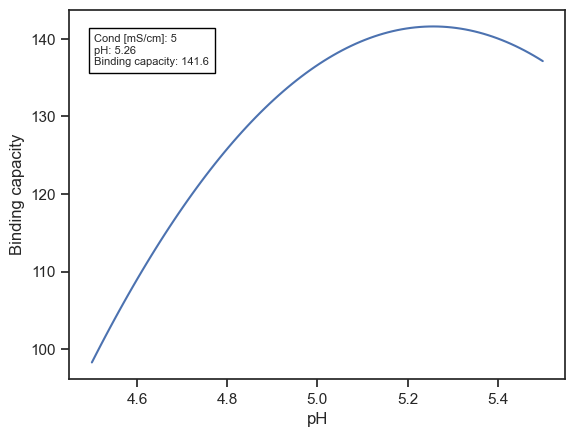

In [18]:
model.constant_plot(value=("Cond [mS/cm]", 5), loc=(0.05, 0.85))